In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy :", np.__version__)
print("Pandas :", pd.__version__)
print("Tout est prêt !")

NumPy : 2.4.3
Pandas : 3.0.1
Tout est prêt !


In [3]:
# Les structures qu'on utilisera tout le temps
donnees_brutes = [23, 45, 12, 67, 34, 89, 23, 45, 56]

# Version classique
total = 0
for x in donnees_brutes:
    total += x
moyenne = total / len(donnees_brutes)

# Version data scientist (1 ligne)
moyenne_pro = sum(donnees_brutes) / len(donnees_brutes)

print(f"Moyenne classique : {moyenne:.2f}")
print(f"Moyenne pro : {moyenne_pro:.2f}")

Moyenne classique : 43.78
Moyenne pro : 43.78


In [4]:
tableau = np.array(donnees_brutes)

print("Moyenne :", tableau.mean())
print("Écart-type :", tableau.std())
print("Min :", tableau.min(), "| Max :", tableau.max())

Moyenne : 43.77777777777778
Écart-type : 22.8656840302852
Min : 12 | Max : 89


In [5]:
# Un DataFrame = un tableau Excel intelligent
etudiants = pd.DataFrame({
    "nom": ["Alice", "Bob", "Carol", "David"],
    "age": [22, 25, 23, 28],
    "score": [88, 72, 95, 61],
    "ville": ["Douala", "Yaoundé", "Douala", "Bafoussam"]
})

print(etudiants)
print("\nStatistiques :")
print(etudiants.describe())

     nom  age  score      ville
0  Alice   22     88     Douala
1    Bob   25     72    Yaoundé
2  Carol   23     95     Douala
3  David   28     61  Bafoussam

Statistiques :
             age      score
count   4.000000   4.000000
mean   24.500000  79.000000
std     2.645751  15.383974
min    22.000000  61.000000
25%    22.750000  69.250000
50%    24.000000  80.000000
75%    25.750000  89.750000
max    28.000000  95.000000


In [13]:
etudiants.keys

<bound method NDFrame.keys of      nom  age  score      ville
0  Alice   22     88     Douala
1    Bob   25     72    Yaoundé
2  Carol   23     95     Douala
3  David   28     61  Bafoussam>

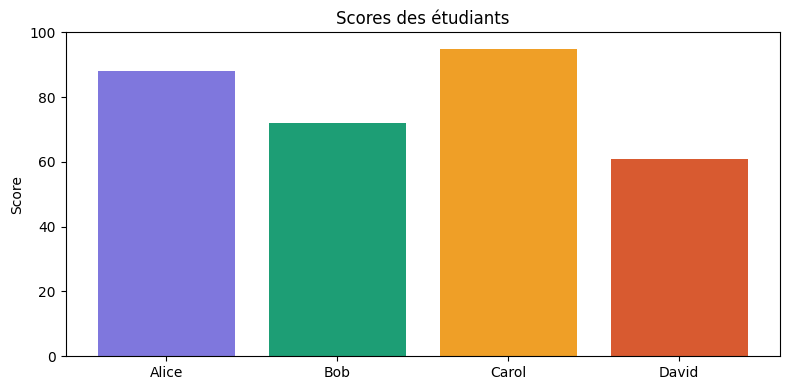

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(etudiants["nom"], etudiants["score"], 
        color=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
plt.title("Scores des étudiants")
plt.ylabel("Score")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

   mois  revenu_par_client
0   Jan       19565.217391
1   Fév       18571.428571
2   Mar       19200.000000
3   Avr       17941.176471
4   Mai       19032.258065
5  Juin       18000.000000
Le meilleur mois est le mois de : Juin avec un montant de 720000 


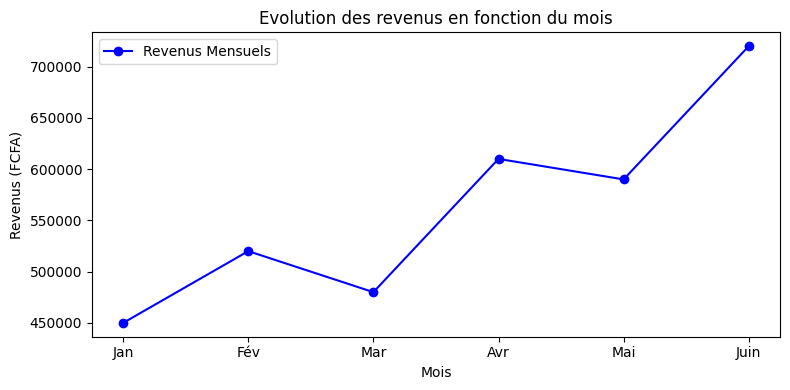

In [44]:
# 1-Crée un DataFrame avec ces données
ventes = {
    "mois": ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin"],
    "revenus": [450000, 520000, 480000, 610000, 590000, 720000],
    "clients": [23, 28, 25, 34, 31, 40]
}
df=pd.DataFrame(ventes)

#2- Revenu moyen PAR CLIENT pour chaque mois
df["revenu_par_client"] = df["revenus"] / df["clients"]
print(df[["mois", "revenu_par_client"]])

#3-Trouve le mois avec le meilleur revenu
index_max = df["revenus"].idxmax()# je trouve d'abord l'indice du revenu maximal
max=df["revenus"].max()
meilleurMois = df.loc[index_max, "mois"]
print(f'Le meilleur mois est le mois de : {meilleurMois} avec un montant de {max} ')

#4-Trace un graphique montrant l'évolution des revenus
plt.figure(figsize=(8, 4))
plt.plot(df['mois'], df['revenus'], marker='o', linestyle='-', color='b', label='Revenus Mensuels')
plt.title("Evolution des revenus en fonction du mois")
plt.xlabel("Mois")
plt.ylabel("Revenus (FCFA)")
plt.legend()
plt.tight_layout()
plt.show()  # ← manquait !

In [18]:
df.describe()

,revenus,clients
count,6.000000,6.000000
mean,561666.666667,30.166667
std,99079.092985,6.242329
min,450000.000000,23.000000
25%,490000.000000,25.750000
50%,555000.000000,29.500000
75%,605000.000000,33.250000
max,720000.000000,40.000000


In [43]:
df["revenu_par_client"] = df["revenus"] / df["clients"]
print(df[["mois", "revenus", "clients", "revenu_par_client"]].to_string(index=False))

# Mois avec le meilleur revenu total
index_max_revenu = df["revenus"].idxmax()
print(f"\nMeilleur revenu total : {df.loc[index_max_revenu, 'mois']} ({df.loc[index_max_revenu, 'revenus']} FCFA)")

# Mois avec le meilleur revenu PAR CLIENT
index_max_par_client = df["revenu_par_client"].idxmax()
print(f"Meilleur revenu par client : {df.loc[index_max_par_client, 'mois']} ({df.loc[index_max_par_client, 'revenu_par_client']:.0f} FCFA/client)")

mois  revenus  clients  revenu_par_client
 Jan   450000       23       19565.217391
 Fév   520000       28       18571.428571
 Mar   480000       25       19200.000000
 Avr   610000       34       17941.176471
 Mai   590000       31       19032.258065
Juin   720000       40       18000.000000

Meilleur revenu total : Juin (720000 FCFA)
Meilleur revenu par client : Jan (19565 FCFA/client)


*NB*: On peut constater que le meilleur revenu total c'est au mois de Juin mais le meilleur revenu par client c'est le mois de Janvier. Faut toujours faire les calculs pour confirmer ou infirmer les resulats vu sur le graphique